# Homework 7 - San Francisco airport wind 

Your assignment is to visualize and analyze wind data collected at the San Francisco airport (SFO) in 2010. The data file is 'SFO_2010_wind_data.csv'

Use these data to answer the following questions:

**Were the winds stronger in January or July? The 'HLY-WIND-VCTSPD' column provides the vector speed (in knots)**
- Make histograms of the wind speeds in each month.
- Calculate the mean, and standard deviation. Also calculate the median and 84th/16th percentiles.

**Were the winds different directions in January and July? The 'HLY-WIND-VCTDIR' column provides the vector azimuth. Note the wind directions indicate the direction the wind is coming from.**
- To visualize this data we will make use of rose diagrams, you can read more about these below.
- Plot up the vector directions using a rose diagram. 
- The issue is, are a histogram (rose diagram) of the wind vector directions the best way to demonstrate this data? Think of the question this way: if one row has a wind with a vector at 10 degrees from North and a speed of 2 knots and the next day has a wind vector at 90 degrees from North and a speed of 20 knots should we be giving these vectors equal 'weighting' when we plot up our data?
- What you need to do is calculate the vector mean wind direction (this is different to the arthimatic mean) and add that to the rose diagram for each time period. I've included a method of how to do this for the entire dataset below (with explanations), you need to do the same for each individual time period.
    
**Do the same comparisons for early morning hours (3 to 8 am; HOUR 3 to 8) and late afternoon hours (1 to 6 pm; HOUR 13 to 19) in July, August, and September (i.e., compare morning and afternoon across teh summer months).**

**Write a summary where you compare and constrast the winter to summer wind data and the morning to afternoon wind data. Describe the processes at play referring to what you heard in the meteorology weather radio piece and infographic.**

Use Markdown cells to explain the methods used and the code that you have written. What do you think drives differences in morning/afternoon and summer/winter winds?

## Questions
1. Were the winds stronger in January or July? The 'HLY-WIND-VCTSPD' column provides the vector speed (in knots)?
1. Were the winds different directions in January and July?
    - The 'HLY-WIND-VCTDIR' column provides the vector azimuth. Note the wind directions indicate the direction the wind is coming from.
1. Do the same comparisons for early morning hours (3 to 8 am; HOUR 3 to 8) and late afternoon hours (1 to 6 pm; HOUR 13 to 19) in July, August, and September (i.e., compare morning and afternoon across teh summer months).
1. Write a summary where you compare and contrast the winter to summer wind data and the morning to afternoon wind data.
    - Describe the processes at play referring to what you heard in the meteorology weather radio piece and infographic.
    - What do you think drives differences in morning/afternoon and summer/winter winds?

In [16]:
### Import more libraries as needed
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
wind = pd.read_csv('data/SFO_2010_wind_data.csv')
wind.head()

,STATION,NAME,DATE,HLY-WIND-1STDIR,HLY-WIND-1STPCT,HLY-WIND-2NDDIR,HLY-WIND-2NDPCT,HLY-WIND-AVGSPD,HLY-WIND-PCTCLM,HLY-WIND-VCTDIR,HLY-WIND-VCTSPD,YEAR,MONTH,DAY,HOUR
0,USW00023234,"SAN FRANCISCO INTERNATIONAL AIRPORT, CA US",01-01T01:00:00,4,172,5,150,6.5,227,183,1.4,2010,1,1,1
1,USW00023234,"SAN FRANCISCO INTERNATIONAL AIRPORT, CA US",01-01T02:00:00,4,167,6,141,6.8,176,178,1.3,2010,1,1,2
2,USW00023234,"SAN FRANCISCO INTERNATIONAL AIRPORT, CA US",01-01T03:00:00,4,187,5,150,6.3,200,178,1.5,2010,1,1,3
3,USW00023234,"SAN FRANCISCO INTERNATIONAL AIRPORT, CA US",01-01T04:00:00,4,179,5,139,6.2,228,171,1.3,2010,1,1,4
4,USW00023234,"SAN FRANCISCO INTERNATIONAL AIRPORT, CA US",01-01T05:00:00,5,177,4,168,6.4,198,181,1.5,2010,1,1,5


## Plotting directions and calculating vector means

Here I'm going to demonstrate the processes that you need to do for the individual, filtered datasets (i.e., the month of July) but instead apply it to the entire dataset. First, we'll demonstrate how to plot the azimuth of wind directions using Rose diagrams. After that I will provide a function that allows us to calculate the mean wind vector, taking into account the recorded speed associated with each vector direction.


### Azimuth

Earth science is filled with directional data. The most typical way that directional data are reported is as azimuth:

<img src="./figures/azimuth.png" width = 300>

### Rose diagrams

*Text modified from Lisa Tauxe's materials for her Python for Earth Science Students course: https://github.com/ltauxe/Python-for-Earth-Science-Students*

As Earth scientists, we like to make plots that convey the most information with the least amount of effort for the viewer.  2D directional data are much better represented as 'rose diagrams', which are really just histograms plotted around a circle. They are also known as _polar_ projections as they could be used to make a map of the Earth looking down at one of the poles.  

We will follow these steps: 

- For rose diagrams, we will create a  plot instance (called ```fig```) with the ```plt.subplot( )``` function.  We make it a _polar_ plot by setting the ```polar``` keyword to ```True```. 
- The _polar_ type of subplot has funny coordinates set as default, funny to an Earth scientist at least.  The orientations go around counterclockwise instead of clockwise (like map directions). To make it seem more normal for Earth science data,  we have to switch around the directions to geographic coordinates.  We do this with the **fig.set_theta_direction(-1)** function where the '-1' tells **matplotlib** that we want the numbers to go around clockwise, instead of the default (which for some unknown reason goes counter clockwise).  
- We also have to put '0' at the top of the diagram (because it is 'North' in Earth science).  We do that with the ```fig.set_theta_zero_location('N')``` call, which tells ```matplotlib``` to put 0 on top (instead of on the right side which is the default).  
-  We have to define some bins, sort of like histograms but around azimuthal circle, and count up how many directions are in each bin.  We will use a bin size of 10$^{\circ}$.  Fortunately, ```plt.hist( )``` will count up the number of directional data in each bin for us! Usually we just use ```plt.hist()``` to make the plot, but we can also have it return the bins and the number in each bin.
- We will use the  plot function **plt.bar( )** which normally makes bar charts, but will make rose diagrams if the plot is _polar_.
- Finally, we will plot the data on the figure instance. 

Let's start with **plt.hist( )** to count up the number of recorded wind directions in each bin. 

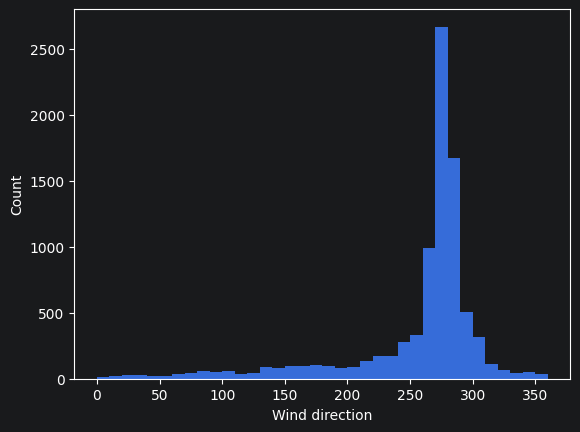

In [3]:
width = 10 # width of the azimuthal bins
binarray = np.arange(0,360+width,width) # make an array to use for bins in plt.hist

bins = binarray[0:-1] # delete the last bin
thetas = np.radians(bins) # convert the binarray to radians.  
widths = np.radians(np.ones(len(thetas))*width) # make the widths array

azimuth_counts, azimuth_bins, patches = plt.hist(wind['HLY-WIND-VCTDIR'],bins=binarray) # get back the counts
plt.xlabel('Wind direction')
plt.ylabel('Count')
plt.show()

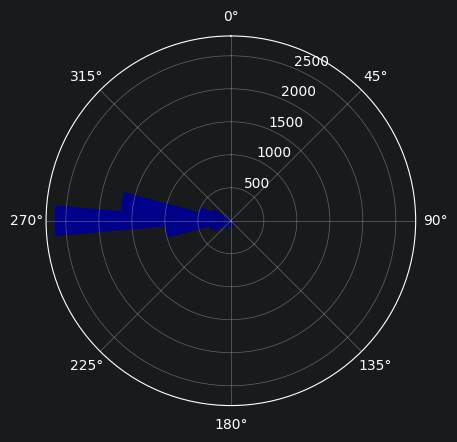

In [4]:
# make the figure instance
fig = plt.subplot(111, polar=True) # Specify polar axes
# set the coordinates the way we want them
fig.set_theta_direction(-1) # Reverse direction of degrees (CW)
fig.set_theta_zero_location("N") # Specify 0-degrees as North
# use the polar "bar" plot.   
fig.bar(thetas, azimuth_counts, width=widths, bottom=0, color='darkblue')
plt.show()

### Vector means

#### Getting the x length and y length of the vector associated with each wind measurement

<img src="./figures/Circle_cos_sin.gif" width = 600>

First determine the relative contribution of the x and y directions to a unit vector with some simple trigonometry:

If $\theta=0º$, $sin(\theta)=0$ and $cos(\theta)=1$

If $\theta=90º$ $sin(\theta)=1$ and $cos(\theta)=0$

If $\theta=225º$ $sin(\theta)= -0.7071$ and $cos(\theta)= -0.7071$

Ultimately, for our purposes, the result is that:

$$ x_{length} = \sin(azimuth) $$

$$ y_{length} = \cos(azimuth) $$

<img src="./figures/2D_Direction_Vectors.svg" width = 600>


#### Calculations in this notebook

To calculate the mean wind direction I'm going to provide a function that takes the wind speed and azimuth to calculate a x-length and y-length for each entry. What you need to do is use these functions to calculate the average wind speed direction for each time period/date specified in the questions above and add these values to the rose diagrams as below:

In [5]:
def get_vector_lengths(azimuth, speed): # take the azimuth and speed from the wind data
    azimuth_radians = np.radians(azimuth) # convert the azimuth into radians so it can be used below
    x_length = speed*np.sin(azimuth_radians) # calculate the x length of the vector
    y_length = speed*np.cos(azimuth_radians) # calculate the y length of the vector
    return x_length,y_length

In [6]:
# for every entry in the dataset I can now calculate an x and y length for the vector
x_lengths, y_lengths = get_vector_lengths(wind['HLY-WIND-VCTDIR'], wind['HLY-WIND-VCTSPD'])

In [48]:
# Insert into df
wind['x'] = x_lengths
wind['y'] = y_lengths

In [7]:
# to determine the mean direction of the wind vector we can then use the code below
def mean_angular_direction(x_total,y_total):
    if (x_total > 0) & (y_total > 0):
        angle = np.rad2deg(np.arctan(x_total/y_total))
    elif (x_total > 0) & (y_total < 0):
        angle = 180+np.rad2deg(np.arctan(x_total/y_total))
    elif (x_total < 0) & (y_total < 0):
        angle = 180+np.rad2deg(np.arctan(x_total/y_total))
    elif (x_total < 0) & (y_total > 0):
        angle = 360+np.rad2deg(np.arctan(x_total/y_total))
    return(angle)

In [8]:
# using that function I can then calculate the mean direction with the summed x lengths and y lengths
angle = mean_angular_direction(np.sum(x_lengths), np.sum(y_lengths))
angle

np.float64(277.1288539074664)

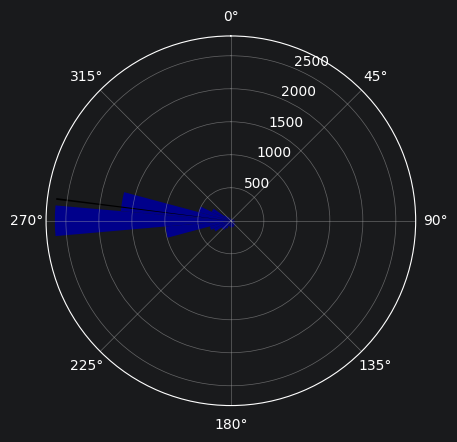

In [9]:
# make the figure instance
fig = plt.subplot(111, polar=True) # Specify polar axes
# set the coordinates the way we want them
fig.set_theta_direction(-1) # Reverse direction of degrees (CW)
fig.set_theta_zero_location("N") # Specify 0-degrees as North
# use the polar "bar" plot.   
fig.bar(thetas, azimuth_counts, width=widths, bottom=0, color='darkblue')
# add a line to demonstrate the mean vector direction
plt.bar(np.radians(angle), np.max(azimuth_counts), width=0.01,bottom=0, color='black')
plt.show()

---
Beginning of the Analysis
## Q1: Were the winds stronger in January or July?
The 'HLY-WIND-VCTSPD' column provides the vector speed (in knots)?

In [14]:
wind.columns

Index(['STATION', 'NAME', 'DATE', 'HLY-WIND-1STDIR', 'HLY-WIND-1STPCT',
       'HLY-WIND-2NDDIR', 'HLY-WIND-2NDPCT', 'HLY-WIND-AVGSPD',
       'HLY-WIND-PCTCLM', 'HLY-WIND-VCTDIR', 'HLY-WIND-VCTSPD', 'YEAR',
       'MONTH', 'DAY', 'HOUR'],
      dtype='str')

In [12]:
wind["HLY-WIND-VCTSPD"].head()

0    1.4
1    1.3
2    1.5
3    1.3
4    1.5
Name: HLY-WIND-VCTSPD, dtype: float64

In [34]:
# prepare data
jan_data = wind[wind['MONTH'] == 1]['HLY-WIND-VCTSPD'].dropna()
jul_data = wind[wind['MONTH'] == 7]['HLY-WIND-VCTSPD'].dropna()

As described in the assignment detail, I will make histograms of the wind speeds in each month and calculate the mean, standard deviation, median and 84th/16th percentiles.

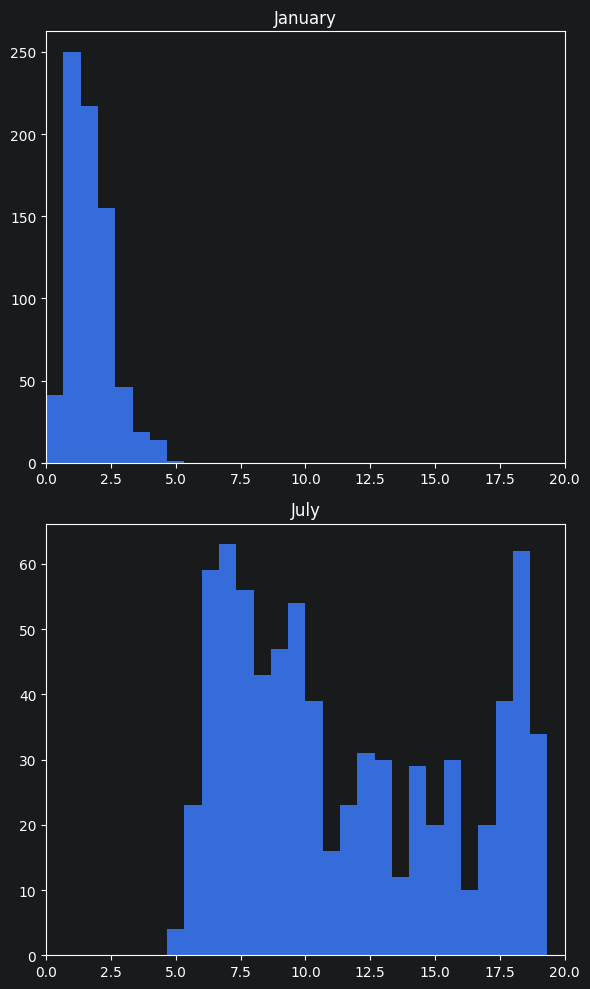

In [35]:
plt.figure(figsize=(6, 10))

plt.subplot(2, 1, 1)
plt.hist(jan_data, bins=30, range=(0, 20))
plt.title('January')
plt.xlim(0, 20)

plt.subplot(2, 1, 2)
plt.hist(jul_data, bins=30, range=(0, 20))
plt.title('July')
plt.xlim(0, 20)

plt.tight_layout()
plt.show()

In [36]:
for name, data in [('January', jan_data), ('July', jul_data)]:
    print(name)
    print(f"Mean: {np.mean(data)}")
    print(f"Std: {np.std(data)}")
    print(f"Median: {np.median(data)}")
    print(f"16th: {np.percentile(data, 16)}")
    print(f"84th: {np.percentile(data, 84)}\n")

January
Mean: 1.6808882907133245
Std: 0.8052056521777294
Median: 1.5
16th: 0.9
84th: 2.4

July
Mean: 11.593548387096773
Std: 4.332505457351585
Median: 10.5
16th: 6.9879999999999995
84th: 17.5



### Answer to Q1: Winds in July is stronger than January.

---
## Q2: Were the winds different directions in January and July?
- The 'HLY-WIND-VCTDIR' column provides the vector azimuth. Note the wind directions indicate the direction the wind is coming from.

January Mean Direction: 201.62
July Mean Direction: 285.11


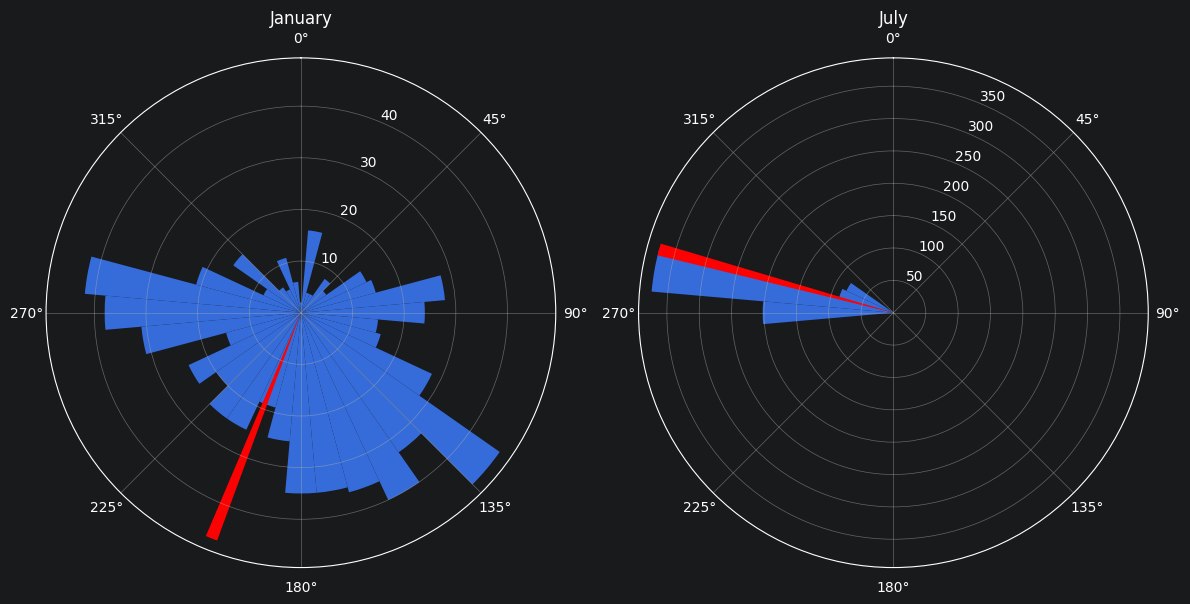

In [53]:
plt.figure(figsize=(12, 6))

for i, month in enumerate([1, 7]):
    data = wind[wind['MONTH'] == month].dropna(subset=['HLY-WIND-VCTDIR', 'HLY-WIND-VCTSPD'])

    mean_angle = mean_angular_direction(data['x'].sum(), data['y'].sum())

    counts, edges = np.histogram(data['HLY-WIND-VCTDIR'], bins=np.linspace(0, 360, 37))
    thetas = np.radians(edges[:-1])
    widths = np.radians(10)

    ax = plt.subplot(1, 2, i + 1, polar=True)
    ax.set_theta_direction(-1)
    ax.set_theta_zero_location("N")
    ax.bar(thetas, counts, width=widths, bottom=0)
    ax.bar(np.radians(mean_angle), np.max(counts), width=0.05, bottom=0, color='red')
    ax.set_title('January' if month == 1 else 'July')

    print(f"{'January' if month == 1 else 'July'} Mean Direction: {mean_angle:.2f}")

plt.tight_layout()
plt.show()

### Answer to Q2: Yes, the winds were from different directions in January and July.
- January Mean Direction: 201.62
- July Mean Direction: 285.11

---
## Q3. Do the same comparisons
for early morning hours (3 to 8 am; HOUR 3 to 8) and late afternoon hours (1 to 6 pm; HOUR 13 to 19) in July, August, and September (i.e., compare morning and afternoon across the summer months).

In [59]:
morning_subset = wind[(wind['MONTH'].isin([7, 8, 9])) & (wind['HOUR'] >= 3) & (wind['HOUR'] <= 8)].dropna(subset=['HLY-WIND-VCTDIR'])
afternoon_subset = wind[(wind['MONTH'].isin([7, 8, 9])) & (wind['HOUR'] >= 13) & (wind['HOUR'] <= 19)].dropna(subset=['HLY-WIND-VCTDIR'])

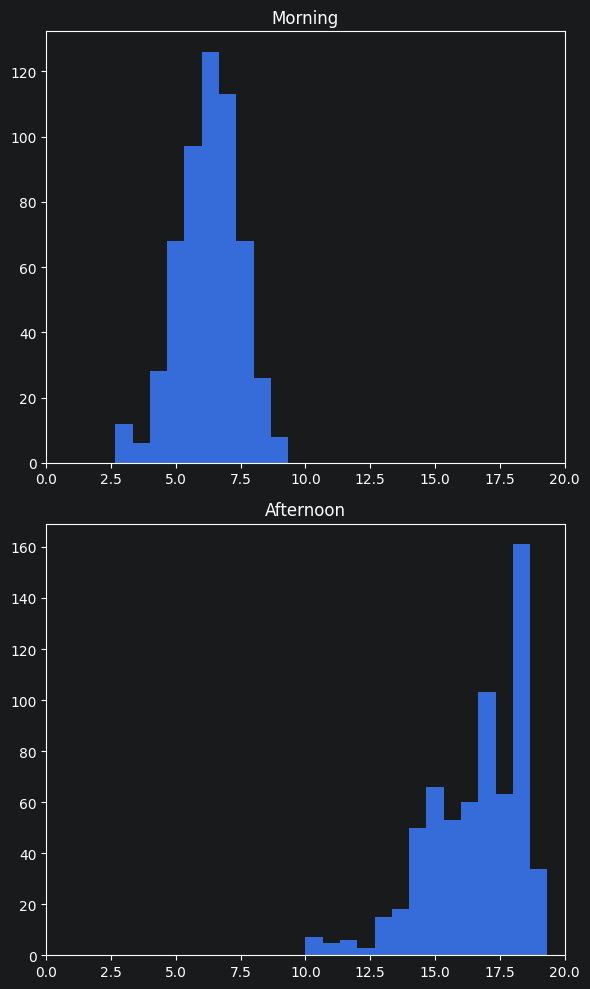

In [62]:
plt.figure(figsize=(6, 10))

plt.subplot(2, 1, 1)
plt.hist(morning_subset['HLY-WIND-VCTSPD'], bins=30, range=(0, 20))
plt.title('Morning')
plt.xlim(0, 20)

plt.subplot(2, 1, 2)
plt.hist(afternoon_subset['HLY-WIND-VCTSPD'], bins=30, range=(0, 20))
plt.title('Afternoon')
plt.xlim(0, 20)

plt.tight_layout()
plt.show()

Morning Mean Direction: 273.11
Afternoon Mean Direction: 285.49


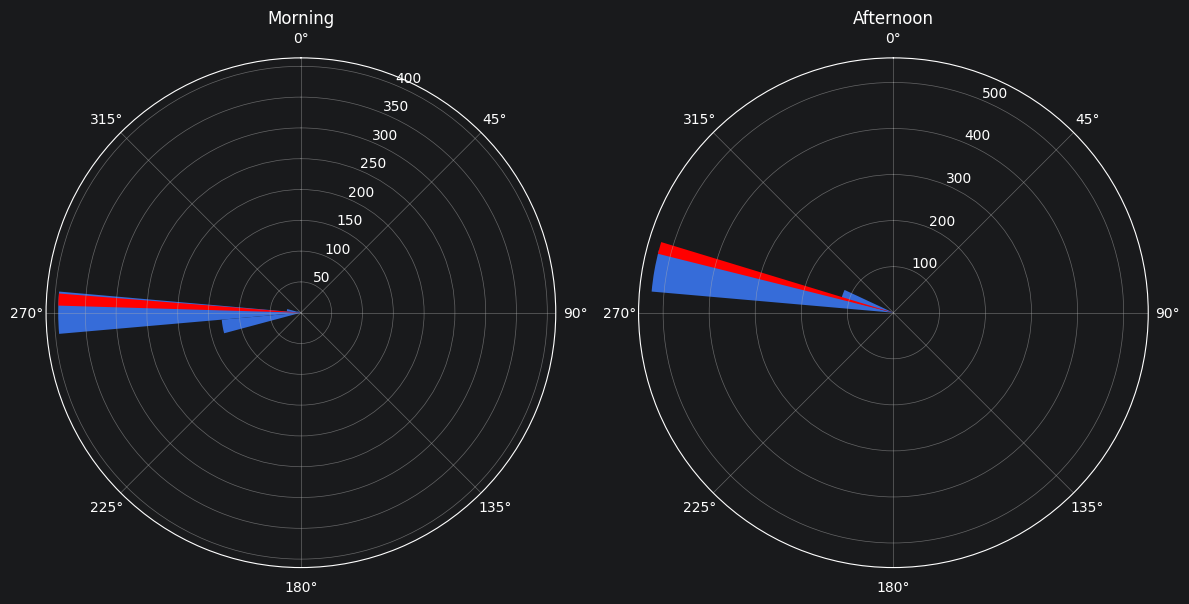

In [61]:
plt.figure(figsize=(12, 6))

for i, (name, subset) in enumerate([('Morning', morning_subset), ('Afternoon', afternoon_subset)]):
    mean_angle = mean_angular_direction(subset['x'].sum(), subset['y'].sum())

    counts, edges = np.histogram(subset['HLY-WIND-VCTDIR'], bins=np.linspace(0, 360, 37))
    thetas = np.radians(edges[:-1])

    ax = plt.subplot(1, 2, i + 1, polar=True)
    ax.set_theta_direction(-1)
    ax.set_theta_zero_location("N")
    ax.bar(thetas, counts, width=np.radians(10), bottom=0)
    ax.bar(np.radians(mean_angle), np.max(counts), width=0.05, bottom=0, color='red')
    ax.set_title(name)

    print(f"{name} Mean Direction: {mean_angle:.2f}")

plt.tight_layout()
plt.show()

### Answer to Q3: The winds were from different directions in the morning and afternoon.
- Morning Mean Direction: 273.11
- Afternoon Mean Direction: 285.49

---
## Q4: Write a summary where you compare and contrast the winter to summer wind data and the morning to afternoon wind data.
- Describe the processes at play referring to what you heard in the meteorology weather radio piece and infographic.
- What do you think drives differences in morning/afternoon and summer/winter winds?

### Answer to Q4
- Winds in summer (July) are from the west (reinforced by the movement of air in land caused by the temperature difference between land and sea) while the winds in winter (January) are from the south due to the storm effect.
- Winds in summer are stronger than winds in winter because the temperature difference effect is greater in hotter climate (summer).
- Comparing morning and afternoon in summer, the winds become even stronger because of the greater temperature difference effect during the day and shift more towards the northwest (from 273° to 285°) in the afternoon.

Reference: Starratt, S. W. (2001). . . . And the Fog Will Burn Off By Noon—A Brief Introduction to the Weather of the San Francisco Bay Area. https://pubs.usgs.gov/bul/b2188/b2188ch7.pdf